# Model Validation, Overfitting Control & Hyperparameter Tuning

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Dataset

In [42]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data Preparation

In [43]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

## Feature Scaling

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train-Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Linear Regression

In [46]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_train_pred = lr.predict(X_train)
lr_test_pred = lr.predict(X_test)

lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_pred))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))

lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)

print("Linear Test R2:", lr_test_r2)

Linear Test R2: 0.575787706032451


## Ridge Regression

In [47]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_train_pred = ridge.predict(X_train)
ridge_test_pred = ridge.predict(X_test)

ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_train_pred))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print("Ridge Test R2:", ridge_test_r2)

Ridge Test R2: 0.5758185345441319


Ridge Regression improves Linear Regression by adding regularization,
which helps reduce overfitting and improve model stability.

## Decision Tree (Overfitting)

In [48]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

tree_train_pred = tree.predict(X_train)
tree_test_pred = tree.predict(X_test)

tree_train_rmse = np.sqrt(mean_squared_error(y_train, tree_train_pred))
tree_test_rmse = np.sqrt(mean_squared_error(y_test, tree_test_pred))

tree_train_r2 = r2_score(y_train, tree_train_pred)
tree_test_r2 = r2_score(y_test, tree_test_pred)

The Decision Tree shows extremely low training error but higher test error,
indicating overfitting.

## Cross Validation

In [49]:
cv_scores = cross_val_score(
    tree, X_scaled, y, cv=5, scoring='neg_mean_squared_error'
)

cv_rmse = np.sqrt(-cv_scores)
print("Average CV RMSE:", cv_rmse.mean())

Average CV RMSE: 0.8957031908951016


Cross-validation provides a more reliable estimate of model performance.

## Hyperparameter Tuning

In [50]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


Hyperparameter tuning helps reduce overfitting by controlling tree complexity.

## Tuned Decision Tree

In [51]:
best_tree = grid.best_estimator_

tuned_train_pred = best_tree.predict(X_train)
tuned_test_pred = best_tree.predict(X_test)

tuned_train_rmse = np.sqrt(mean_squared_error(y_train, tuned_train_pred))
tuned_test_rmse = np.sqrt(mean_squared_error(y_test, tuned_test_pred))

tuned_train_r2 = r2_score(y_train, tuned_train_pred)
tuned_test_r2 = r2_score(y_test, tuned_test_pred)

## Model Comparison

In [52]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Tree", "Tuned Tree"],
    "Train RMSE": [lr_train_rmse, ridge_train_rmse, tree_train_rmse, tuned_train_rmse],
    "Test RMSE": [lr_test_rmse, ridge_test_rmse, tree_test_rmse, tuned_test_rmse],
    "Train R2": [lr_train_r2, ridge_train_r2, tree_train_r2, tuned_train_r2],
    "Test R2": [lr_test_r2, ridge_test_r2, tree_test_r2, tuned_test_r2]
})

results.round(4)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear,0.7197,0.7456,0.6126,0.5758
1,Ridge,0.7197,0.7456,0.6126,0.5758
2,Tree,0.0000,0.7030,1.0000,0.6228
3,Tuned Tree,0.4866,0.6389,0.8229,0.6885


## Model Comparison Graphs

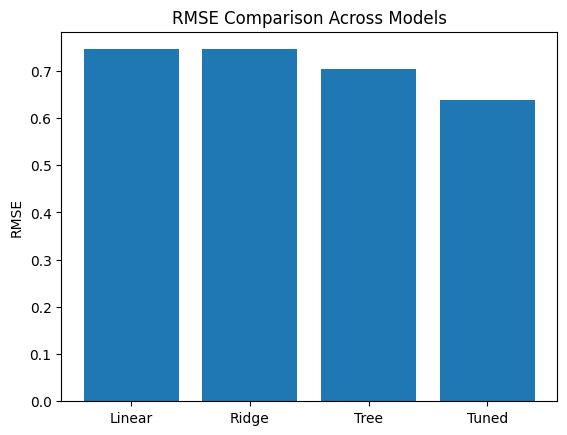

In [53]:
models = ["Linear", "Ridge", "Tree", "Tuned"]

plt.figure()
plt.bar(models, [lr_test_rmse, ridge_test_rmse, tree_test_rmse, tuned_test_rmse])
plt.title("RMSE Comparison Across Models")
plt.ylabel("RMSE")
plt.show()

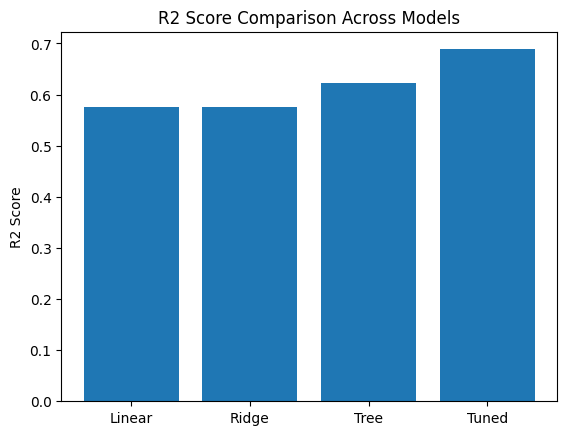

In [55]:
plt.figure()
plt.bar(models, [lr_test_r2, ridge_test_r2, tree_test_r2, tuned_test_r2])
plt.title("R2 Score Comparison Across Models")
plt.ylabel("R2 Score")
plt.show()

## Final Conclusion

- Linear models provided stable but limited performance
- Decision Tree overfitted the data
- Cross-validation improved evaluation reliability
- Hyperparameter tuning reduced overfitting

The Tuned Decision Tree achieved the best balance between accuracy and generalization.

## Key Learnings

- Overfitting detection using train/test comparison
- Importance of cross-validation
- Role of hyperparameter tuning
- Model selection based on generalization